In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

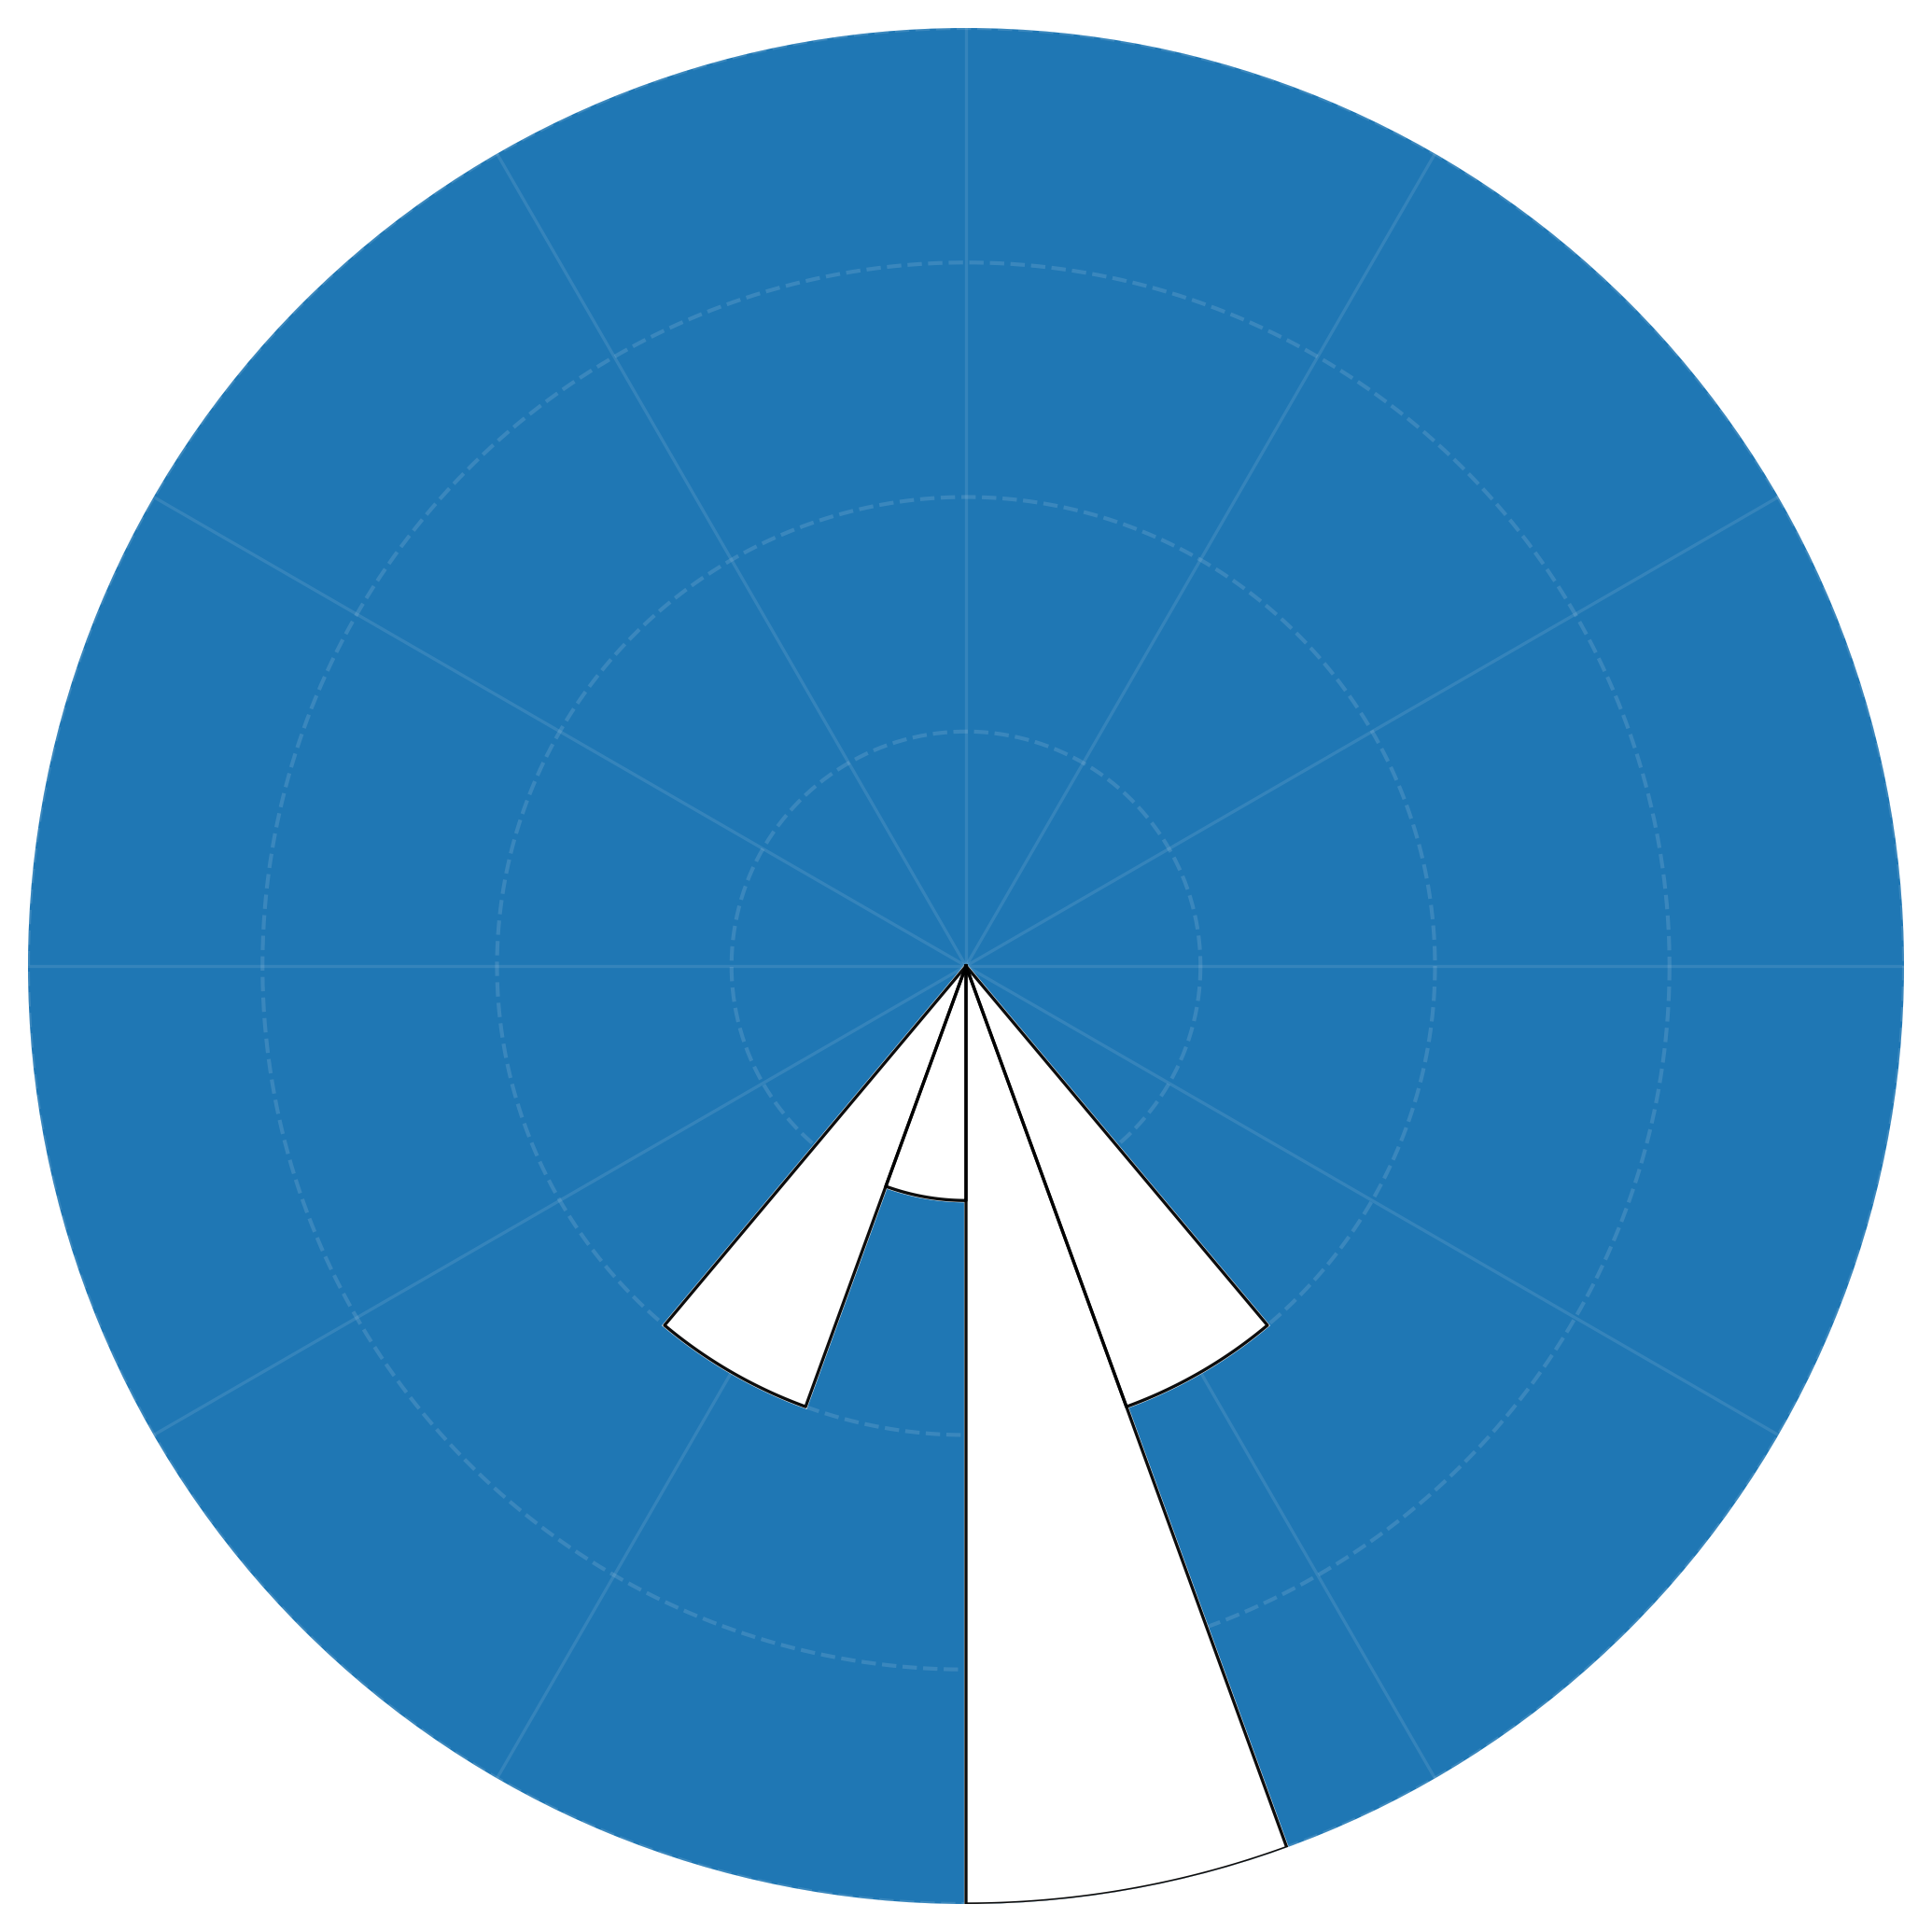

In [8]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# =============================================================================
# DATA  —  (azimuth_degrees, frequency)
# =============================================================================
DATA = [
    (77, 1), (76, 1), (120, 1), (135, 1), (90, 1), (88, 1), (93, 1), (100, 1), (88, 1),
]

# =============================================================================
# SETTINGS
# =============================================================================

# --- Data ---
BIN_SIZE_DEG   = 20        # Petal width in degrees
BIDIRECTIONAL  = False     # Mirror petals 180° (for fracture/fault data)
NORMALISE_MODE = "percent" # "percent" or "frequency"

# --- Figure ---
FIGURE_SIZE      = (7, 7)
FIGURE_DPI       = 300
BACKGROUND_COLOR = None  # Both figure and axes

# --- Petals ---
PETAL_COLOR      = "white"
PETAL_ALPHA      = 1
PETAL_EDGE_COLOR = "k"
PETAL_EDGE_ALPHA = 0.95
PETAL_EDGE_WIDTH = 0.8
PETAL_EDGE_STYLE = "-"       # "-", "--", "-.", ":"

# --- Rings ---
SHOW_RINGS       = True
N_RINGS          = 4
RING_COLOR       = "white"
RING_ALPHA       = 0.12
RING_LINEWIDTH   = 1
RING_LINESTYLE   = "--"

# --- Spokes ---
SHOW_SPOKES      = True
SPOKE_STEP_DEG   = 30
SPOKE_COLOR      = "white"
SPOKE_ALPHA      = 0.10
SPOKE_LINEWIDTH  = 0.8
SPOKE_LINESTYLE  = "-"

# --- Output ---
SAVE_FILE        = 'BSS_rose_v2.png'    # e.g. "rose.png", or None to skip saving

# =============================================================================
# DRAW
# =============================================================================

# Build bins
n_bins = int(360 / BIN_SIZE_DEG)
bins   = np.zeros(n_bins)
for az, count in DATA:
    idx = int((az % 360) / BIN_SIZE_DEG) % n_bins
    bins[idx] += count
    if BIDIRECTIONAL:
        bins[(idx + n_bins // 2) % n_bins] += count

# Normalise
total  = bins.sum()
values = (bins / total * 100) if (NORMALISE_MODE == "percent" and total > 0) else bins
max_val = values.max() if values.max() > 0 else 1

fig = plt.figure(figsize=FIGURE_SIZE, dpi=FIGURE_DPI, facecolor=BACKGROUND_COLOR)
ax  = fig.add_subplot(111, projection="polar")
ax.set_facecolor(BACKGROUND_COLOR)

# 90° (East in standard math) mapped to top; clockwise direction
# set_theta_zero_location("E") + direction(-1) puts 90° at top
ax.set_theta_zero_location("E")
ax.set_theta_direction(-1)

# Hide all default decorations
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.spines["polar"].set_visible(False)
ax.grid(False)
ax.set_ylim(0, max_val)

# Spokes
if SHOW_SPOKES:
    for deg in range(0, 360, SPOKE_STEP_DEG):
        rad = np.deg2rad(deg)
        ax.plot([rad, rad], [0, max_val],
                color=SPOKE_COLOR, alpha=SPOKE_ALPHA,
                linewidth=SPOKE_LINEWIDTH, linestyle=SPOKE_LINESTYLE, zorder=1)

# Rings
if SHOW_RINGS:
    theta = np.linspace(0, 2 * np.pi, 360)
    for i in range(1, N_RINGS + 1):
        r = (max_val / N_RINGS) * i
        ax.plot(theta, np.full_like(theta, r),
                color=RING_COLOR, alpha=RING_ALPHA,
                linewidth=RING_LINEWIDTH, linestyle=RING_LINESTYLE, zorder=2)

# Petals
half = np.deg2rad(BIN_SIZE_DEG / 2)
for i, val in enumerate(values):
    if val == 0:
        continue
    center_rad  = np.deg2rad(i * BIN_SIZE_DEG)
    theta_arc   = np.linspace(center_rad - half, center_rad + half, 60)
    theta_petal = np.concatenate([[center_rad - half], theta_arc, [center_rad + half]])
    r_petal     = np.concatenate([[0], np.full(60, val), [0]])

    ax.fill(theta_petal, r_petal, color=PETAL_COLOR, alpha=PETAL_ALPHA, zorder=3)
    ax.plot(theta_petal, r_petal,
            color=plt.matplotlib.colors.to_rgba(PETAL_EDGE_COLOR, PETAL_EDGE_ALPHA),
            linewidth=PETAL_EDGE_WIDTH, linestyle=PETAL_EDGE_STYLE, zorder=4)

plt.tight_layout()
if SAVE_FILE:
    plt.savefig(SAVE_FILE, dpi=FIGURE_DPI,  bbox_inches="tight", transparent=True)
plt.show()